# Stage 1A Long V1 Geometry Diagnosis

Bu notebook, `ce_supcon_long_v1` koşusunun `z_long` geometry'yi neden koruduğunu adım adım incelemek için hazırlandı.

Odak sorusu:

> Long pencere gerçekten kullanılıyor mu, yoksa classifier çoğunlukla short branch üzerinden mi çalışıyor?

Bu soruyu tek bir metrikle yanıtlamıyoruz. Sırasıyla branch aktivasyonunu, classifier kullanımını, komşuluk geometry'sini, symbol shortcut riskini ve domain-specific bucket ayrışmasını kontrol ediyoruz.

Bakacağımız ana ölçümler:

- latent shape'leri
- latent normları ve RMS ölçekleri
- classifier first-layer short/long weight normları
- approximate effective long/short contribution
- NN label/symbol agreement
- label centroid vs symbol centroid ayrışması
- bucket centroid distance: clean/borderline/confirmed/wick-sweep ayrımları

Notebook'un ana sonucu şu çerçevede okunmalı:

```text
ce_supcon_long_v1 sadece iyi classifier üretmiyor;
z_long branch'ini aktif, label-dominant ve symbol-suppressed bir structural representation haline getiriyor.
```


## 1. Setup

Bu hücre repo kökünü bulur, `src/` path'ini ekler ve temel kütüphaneleri yükler.

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

from msb_repr.stage1a.analysis import load_checkpoint_bundle

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

REPO_ROOT

PosixPath('/Users/ayimaz/dev/msb-representation')

## 2. Karşılaştırılacak Koşular

Burada dört koşuyu karşılaştırıyoruz:

- `ce_only`: CE-only baseline
- `ce_supcon_long_v1`: başarılı branch-aware SupCon koşusu
- `ce_supcon_long_aux_v2`: pressure-only auxiliary, fakat symbol shortcut geri geldi
- `ce_supcon_long_short_pressure_aux_v1`: pressure head `z_short` üstüne izole edildi, fakat `z_long` çöktü

In [2]:
DATASET_ROOT = REPO_ROOT / "data/stage1a/binance/15m"
CHECKPOINT_ROOT = DATASET_ROOT / "checkpoints"

VARIANTS = {
    "ce_only": CHECKPOINT_ROOT / "ce_only",
    "long_v1": CHECKPOINT_ROOT / "ce_supcon_long_v1",
    "aux_v2": CHECKPOINT_ROOT / "ce_supcon_long_aux_v2",
    "short_pressure_aux_v1": CHECKPOINT_ROOT / "ce_supcon_long_short_pressure_aux_v1",
}

for name, path in VARIANTS.items():
    print(name, path.exists(), path)

ce_only True /Users/ayimaz/dev/msb-representation/data/stage1a/binance/15m/checkpoints/ce_only
long_v1 True /Users/ayimaz/dev/msb-representation/data/stage1a/binance/15m/checkpoints/ce_supcon_long_v1
aux_v2 True /Users/ayimaz/dev/msb-representation/data/stage1a/binance/15m/checkpoints/ce_supcon_long_aux_v2
short_pressure_aux_v1 True /Users/ayimaz/dev/msb-representation/data/stage1a/binance/15m/checkpoints/ce_supcon_long_short_pressure_aux_v1


## 3. Latent Artefactlerini Yükle

Her checkpoint için `analysis/test_latents.npz` dosyasını okuyoruz. Bu dosyada her sample için latent vektörleri var.

Örnek shape okuması:

```text
z_short: [num_samples, 64]
z_long:  [num_samples, 32]
z_fused: [num_samples, 96]
```

In [3]:
def load_latents(checkpoint_dir: Path, split: str = "test") -> dict[str, np.ndarray]:
    latent_path = checkpoint_dir / "analysis" / f"{split}_latents.npz"
    if not latent_path.exists():
        raise FileNotFoundError(latent_path)
    return dict(np.load(latent_path, allow_pickle=True))

latents = {name: load_latents(path, split="test") for name, path in VARIANTS.items()}

shape_rows = []
for name, arrays in latents.items():
    for key in ["z_short", "z_long", "z_fused", "z_long_proj"]:
        if key in arrays:
            shape_rows.append({"variant": name, "embedding": key, "shape": arrays[key].shape})

pd.DataFrame(shape_rows)

,variant,embedding,shape
0,ce_only,z_short,"(9704, 64)"
1,ce_only,z_long,"(9704, 32)"
2,ce_only,z_fused,"(9704, 96)"
3,long_v1,z_short,"(9704, 64)"
4,long_v1,z_long,"(9704, 32)"
5,long_v1,z_fused,"(9704, 96)"
6,long_v1,z_long_proj,"(9704, 32)"
7,aux_v2,z_short,"(9704, 64)"
8,aux_v2,z_long,"(9704, 32)"
9,aux_v2,z_fused,"(9704, 96)"


## 4. Latent Normu

Tek sample için latent normu:

```text
||z|| = sqrt(z1^2 + z2^2 + ... + zn^2)
```

Dataset için her satırın normunu alıp ortalamasını raporluyoruz.

Okuma:

- norm yüksek: branch daha büyük ölçekli latent sinyal üretiyor
- norm düşük: branch daha küçük ölçekli / daha pasif olabilir
- norm tek başına kalite değildir; label/symbol agreement ile birlikte okunmalı

Buradaki kritik karşılaştırma `z_long / z_short` oranıdır. CE-only koşusunda `z_long` normu `z_short`a göre çok küçük kalır; bu, classifier'ın long branch'i kullanmasını zorlaştırır. `long_v1`de bu oran belirgin yükselir, yani long branch daha görünür ve kullanılabilir hale gelir.

`z_long_proj` normunun yüksek çıkması tek başına başarı anlamına gelmez. Projection head SupCon için ayrı bir uzay üretir ve classifier bu vektörü doğrudan kullanmaz. Bu yüzden `z_long_proj` için asıl okuma norm değil, NN label/symbol agreement ve projection-space centroid davranışıdır.


In [4]:
def latent_norm_summary(arrays: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for key in ["z_short", "z_long", "z_fused", "z_long_proj"]:
        if key not in arrays:
            continue
        x = arrays[key]
        norms = np.linalg.norm(x, axis=1)
        rows.append({
            "embedding": key,
            "norm_mean": norms.mean(),
            "norm_std": norms.std(),
            "feature_std_mean": x.std(axis=0).mean(),
        })
    return pd.DataFrame(rows)

norm_df = pd.concat(
    [latent_norm_summary(arrays).assign(variant=name) for name, arrays in latents.items()],
    ignore_index=True,
)[["variant", "embedding", "norm_mean", "norm_std", "feature_std_mean"]]

norm_df.round(4)

,variant,embedding,norm_mean,norm_std,feature_std_mean
0,ce_only,z_short,22.154800,8.4049,1.7652
1,ce_only,z_long,2.578300,2.0344,0.3415
2,ce_only,z_fused,22.430201,8.3156,1.2907
3,long_v1,z_short,12.055700,3.3750,1.0910
4,long_v1,z_long,7.744200,2.4983,0.9954
5,long_v1,z_fused,14.482500,3.6335,1.0591
6,long_v1,z_long_proj,32.864399,28.2428,5.2691
7,aux_v2,z_short,17.269400,6.5539,1.3965
8,aux_v2,z_long,3.252900,2.0620,0.4714
9,aux_v2,z_fused,17.862301,6.0792,1.0881


In [5]:
pivot_norm = norm_df.pivot(index="variant", columns="embedding", values="norm_mean")
pivot_norm["z_long / z_short"] = pivot_norm["z_long"] / pivot_norm["z_short"]
pivot_norm.round(4)

embedding,z_fused,z_long,z_long_proj,z_short,z_long / z_short
variant,,,,,
aux_v2,17.862301,3.2529,18.639099,17.2694,0.1884
ce_only,22.430201,2.5783,NaN,22.1548,0.1164
long_v1,14.482500,7.7442,32.864399,12.0557,0.6424
short_pressure_aux_v1,19.957001,2.0938,26.391199,19.7932,0.1058


## 5. Classifier First Layer Weight Normu

Modelde classifier şu şekilde tanımlı:

```python
self.classifier = nn.Sequential(
    nn.Linear(fused_dim, fused_dim),  # classifier[0]
    nn.LayerNorm(fused_dim),
    nn.ReLU(),
    nn.Dropout(dropout),
    nn.Linear(fused_dim, num_classes),
)
```

`classifier[0].weight` shape'i `[96, 96]`. Bu bir latent vektörü değil, ilk linear katmanın tüm ağırlık matrisidir.

Input kolonları şu sırada:

```text
0..63   -> z_short
64..95  -> z_long
```

Bu yüzden:

```python
W_short = W[:, :64]
W_long  = W[:, 64:]
```

Toplam weight normu, classifier'ın inputun short ve long taraflarına ne kadar ağırlık verdiğini yaklaşık gösterir. RMS ise boyut sayısı farkını normalize eden per-weight ölçek okumasıdır. Short 64 dim, long 32 dim olduğu için toplam norm ve RMS birlikte okunur; ama gerçek branch etkisi için latent ölçeği de hesaba katılmalıdır.


In [6]:
def classifier_weight_summary(checkpoint_dir: Path) -> dict[str, float]:
    bundle = load_checkpoint_bundle(checkpoint_dir, device=torch.device("cpu"))
    model = bundle.model
    z_short_dim = int(bundle.metadata["z_short"])
    W = model.classifier[0].weight.detach().cpu().numpy()
    W_short = W[:, :z_short_dim]
    W_long = W[:, z_short_dim:]
    short_norm = np.linalg.norm(W_short)
    long_norm = np.linalg.norm(W_long)
    short_rms = short_norm / np.sqrt(W_short.size)
    long_rms = long_norm / np.sqrt(W_long.size)
    return {
        "classifier_short_weight_norm": short_norm,
        "classifier_long_weight_norm": long_norm,
        "classifier_long/short": long_norm / short_norm,
        "classifier_short_weight_rms": short_rms,
        "classifier_long_weight_rms": long_rms,
        "classifier_long/short_rms": long_rms / short_rms,
    }

weight_df = pd.DataFrame(
    [{"variant": name, **classifier_weight_summary(path)} for name, path in VARIANTS.items()]
)

weight_df.round(4)

,variant,classifier_short_weight_norm,classifier_long_weight_norm,classifier_long/short,classifier_short_weight_rms,classifier_long_weight_rms,classifier_long/short_rms
0,ce_only,27.375000,16.280600,0.5947,0.3492,0.2937,0.8411
1,long_v1,16.735300,14.243800,0.8511,0.2135,0.2570,1.2037
2,aux_v2,24.882999,20.934099,0.8413,0.3175,0.3777,1.1898
3,short_pressure_aux_v1,23.997601,12.928000,0.5387,0.3062,0.2333,0.7619


## 6. Effective Long/Short Contribution

Yaklaşık branch katkısı:

```text
effective_long/short = classifier_long/short * latent_long/short
```

Bu kesin bir attribution yöntemi değildir. Ama branch'in pratikte ne kadar etkili kullanıldığını görmek için iyi bir diagnostic ölçüdür.

Neden sadece classifier weight oranı yetmez?

Classifier long kolonlarına makul ağırlık vermiş olabilir, fakat `z_long` aktivasyonu çok küçükse bu ağırlıkların pratik etkisi sınırlı kalır. Tersi de geçerlidir: latent büyük ama classifier onu okumuyorsa katkı yine düşük olur.

Bu yüzden `long_v1`in önemli farkı iki tarafın birlikte hareket etmesidir:

```text
z_long ölçeği yükseliyor
classifier long tarafına ağırlık veriyor
effective long/short katkı CE-only seviyesinden belirgin ayrılıyor
```


In [7]:
effective_df = weight_df[["variant", "classifier_long/short", "classifier_long/short_rms"]].merge(
    pivot_norm[["z_long / z_short"]].reset_index(),
    on="variant",
)
effective_df["effective_long/short"] = (
    effective_df["classifier_long/short"] * effective_df["z_long / z_short"]
)
effective_df.round(4)

,variant,classifier_long/short,classifier_long/short_rms,z_long / z_short,effective_long/short
0,ce_only,0.5947,0.8411,0.1164,0.0692
1,long_v1,0.8511,1.2037,0.6424,0.5467
2,aux_v2,0.8413,1.1898,0.1884,0.1585
3,short_pressure_aux_v1,0.5387,0.7619,0.1058,0.0570


Beklenen okuma:

- `ce_only`: long branch çok düşük katkılı
- `long_v1`: long branch gerçek katkı veriyor
- aux koşuları: F1 iyi olsa bile long branch katkısı düşüyor

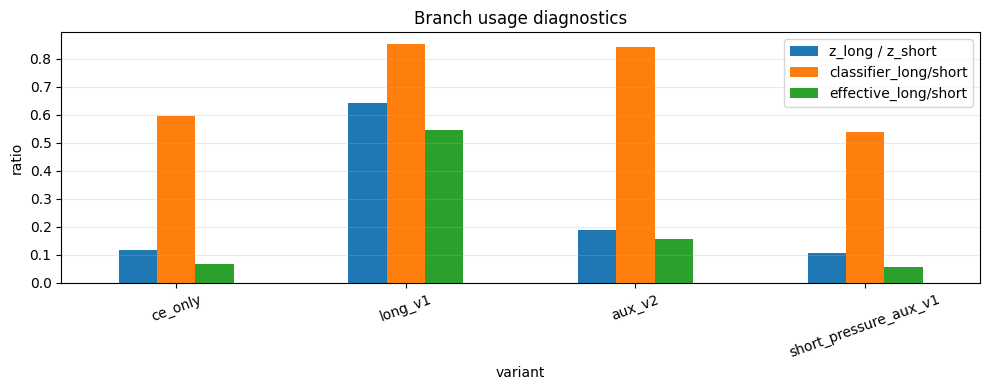

In [8]:
plot_df = effective_df.set_index("variant")[["z_long / z_short", "classifier_long/short", "effective_long/short"]]
ax = plot_df.plot(kind="bar", figsize=(10, 4), rot=20)
ax.set_title("Branch usage diagnostics")
ax.set_ylabel("ratio")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()

### Effective Contribution Sonuç Notu

Bu bölümde beklenen ana sonuç şudur:

```text
ce_only:                 long branch etkili katkısı çok düşük
long_v1:                 long branch etkili katkısı belirgin yükseliyor
aux_v2:                  classifier weight oranı fena değil, fakat z_long ölçeği düşük kaldığı için effective katkı düşüyor
short_pressure_aux_v1:   pressure short'a izole edilse bile long branch etkili katkısı CE-only seviyesine geri dönüyor
```

Bu yüzden `long_v1`in farkı sadece `z_long_proj` üretmesi değil; `z_long`un classifier kararında gerçekten kullanılan bir branch haline gelmesidir.

Önemli çıkarım:

> Auxiliary deneylerde sorun yalnızca pressure gradient'in `z_long`a doğrudan akması değil. Fused eğitim dinamiği short branch'e fazla yaslanınca `z_long`un effective contribution'ı düşüyor ve SupCon geometry tek başına bunu kurtaramıyor.


## 7. NN Label/Symbol Agreement

Burada hazır embedding compare artefactlerini okuyoruz. Bu tablolar latent komşularının ne kadar aynı label'a veya aynı symbol'e sahip olduğunu gösterir.

Komşular `scripts/compare_stage1a_embedding_views.py` çıktısından gelir. Her embedding için cosine similarity ile top-k nearest neighbor hesaplanır; sonra her sample'ın komşularında aynı label ve aynı symbol oranı ölçülür.

İyi durum:

```text
label agreement yüksek
symbol agreement düşük
```

Bu ölçüm lokal geometry'yi okur: tek tek noktaların yakın çevresi structural label'a göre mi oluşmuş, yoksa coin identity'ye göre mi kümelenmiş?


In [9]:
def load_embedding_summary(checkpoint_dir: Path, split: str = "test") -> pd.DataFrame:
    path = checkpoint_dir / "analysis" / f"{split}_embedding_compare" / "embedding_overall_summary.csv"
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)

nn_df = pd.concat(
    [load_embedding_summary(path).assign(variant=name) for name, path in VARIANTS.items()],
    ignore_index=True,
)

nn_df[["variant", "embedding_key", "mean_nn_label_agreement", "mean_nn_symbol_agreement", "top1_label_match_rate", "top1_symbol_match_rate"]].round(4)

,variant,embedding_key,mean_nn_label_agreement,mean_nn_symbol_agreement,top1_label_match_rate,top1_symbol_match_rate
0,aux_v2,z_short,0.8400,0.2774,0.8472,0.3111
1,aux_v2,z_long,0.7963,0.7807,0.8128,0.8739
2,aux_v2,z_fused,0.8457,0.4094,0.8536,0.5280
3,aux_v2,z_long_proj,0.7884,0.6374,0.7935,0.6838
4,short_pressure_aux_v1,z_short,0.8421,0.3075,0.8473,0.3469
5,short_pressure_aux_v1,z_long,0.4742,0.9321,0.6392,0.9790
6,short_pressure_aux_v1,z_fused,0.8424,0.5701,0.8514,0.6704
7,short_pressure_aux_v1,z_long_proj,0.4461,0.9194,0.4931,0.9481


### NN Agreement Sonuç Notu

Bu tabloda iyi pattern:

```text
mean_nn_label_agreement yüksek
mean_nn_symbol_agreement düşük
```

`long_v1`, özellikle `z_long` ve `z_long_proj` için bu pattern'i verir. Bu, yakın komşuların structural label'a göre toplandığını ama aynı sembole aşırı yapışmadığını gösterir.

Aux koşularında pressure probe iyileşse bile `z_long` / `z_long_proj` symbol agreement yükseldiğinde bunu shortcut riski olarak okuyoruz.

Buradaki kritik ders:

> Probe başarısı representation başarısı değildir. Bir probe sinyali okuyabiliyor olsa bile latent uzay aynı sembole aşırı yapışıyorsa Stage 1A'nın ana hedefine zarar verir.


## 8. Label Centroid vs Symbol Centroid Ayrışması

Bu ölçümde embeddingleri normalize edip label centroidleri ve symbol centroidleri arasındaki ayrışmayı ölçüyoruz.

Önce her sample vektörü unit norm yapılır:

```python
x = x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-12)
```

`keepdims=True` norm çıktısını `[num_samples, 1]` tutar; broadcast ile her sample'ın tüm dimension'ları kendi normuna bölünür ve sonuç yine `[num_samples, latent_dim]` olur.

İyi durum:

```text
between_label yüksek
between_symbol düşük
symbol/label düşük
```

Bu ölçüm NN analizinden daha globaldir. NN lokal komşuluk yapısını, centroid analizi ise bütün embedding uzayında label merkezleri ve symbol merkezleri arasındaki ayrımı okur.


In [10]:
def centroid_separation(arrays: dict[str, np.ndarray], embedding_key: str) -> dict[str, float]:
    x = arrays[embedding_key].astype("float64")
    labels = arrays["labels"]
    symbols = arrays["symbols"].astype(str)
    x = x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-12)

    def between(values: np.ndarray) -> float:
        centroids = []
        for value in sorted(set(values.tolist())):
            centroids.append(x[values == value].mean(axis=0))
        centroids = np.stack(centroids)
        global_center = x.mean(axis=0)
        return float(np.mean(np.linalg.norm(centroids - global_center, axis=1)))

    label_sep = between(labels)
    symbol_sep = between(symbols)
    return {
        "between_label": label_sep,
        "between_symbol": symbol_sep,
        "symbol/label": symbol_sep / (label_sep + 1e-12),
    }

centroid_rows = []
for name, arrays in latents.items():
    for key in ["z_short", "z_long", "z_fused", "z_long_proj"]:
        if key in arrays:
            centroid_rows.append({"variant": name, "embedding": key, **centroid_separation(arrays, key)})

centroid_df = pd.DataFrame(centroid_rows)
centroid_df.round(4)

,variant,embedding,between_label,between_symbol,symbol/label
0,ce_only,z_short,0.6335,0.0241,0.0380
1,ce_only,z_long,0.0247,0.5431,21.9595
2,ce_only,z_fused,0.6230,0.0907,0.1456
3,long_v1,z_short,0.5639,0.0469,0.0832
4,long_v1,z_long,0.7145,0.0177,0.0248
5,long_v1,z_fused,0.6080,0.0402,0.0661
6,long_v1,z_long_proj,0.3744,0.0076,0.0203
7,aux_v2,z_short,0.5899,0.0273,0.0463
8,aux_v2,z_long,0.5429,0.1992,0.3669
9,aux_v2,z_fused,0.5918,0.0446,0.0754


,variant,embedding,between_label,between_symbol,symbol/label
1,ce_only,z_long,0.0247,0.5431,21.9595
4,long_v1,z_long,0.7145,0.0177,0.0248
6,long_v1,z_long_proj,0.3744,0.0076,0.0203
8,aux_v2,z_long,0.5429,0.1992,0.3669
10,aux_v2,z_long_proj,0.3543,0.0257,0.0726
12,short_pressure_aux_v1,z_long,0.0386,0.4836,12.5419
14,short_pressure_aux_v1,z_long_proj,0.0016,0.0066,4.2275


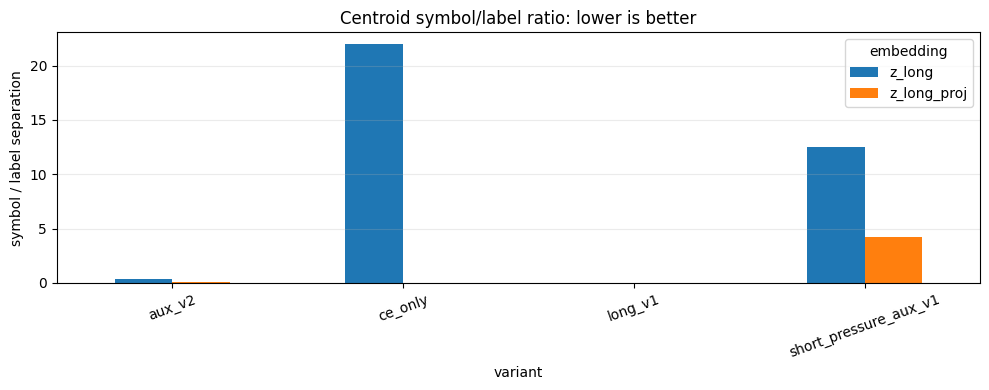

In [11]:
zlong_centroids = centroid_df[centroid_df["embedding"].isin(["z_long", "z_long_proj"])]
display(zlong_centroids.round(4))

ax = zlong_centroids.pivot(index="variant", columns="embedding", values="symbol/label").plot(
    kind="bar", figsize=(10, 4), rot=20
)
ax.set_title("Centroid symbol/label ratio: lower is better")
ax.set_ylabel("symbol / label separation")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()

### Label/Symbol Centroid Sonuç Notu

Bu bölüm NN analizinden daha global bir kontrol sağlar.

`long_v1` için beklenen ve gözlenen iyi pattern:

```text
z_long:      label centroid ayrışması yüksek, symbol centroid ayrışması düşük
z_long_proj: label centroid ayrışması var, symbol centroid ayrışması baskılı
```

Bu, `long_v1`in sadece lokal komşulukta değil, global centroid geometry'de de label-dominant / symbol-suppressed davrandığını doğrular.

Özellikle `short_pressure_aux_v1` burada açık uyarı verir: pressure head short'a taşınsa bile `z_long` centroidleri label yerine symbol ekseninde ayrışır. Bu da yapısal sorunun branch usage balance ve geometry kurulumuyla ilgili olduğunu destekler.


## 9. Bucket Centroid Analizi

Label centroidleri `intact / bullish / bearish` seviyesinde kalır. Bucket centroidleri daha domain-specific bir soruya gider:

> Hard-case structural alt yapılar latent uzayında nasıl konumlanıyor?

Bu bölümü üç okunabilir soruya indiriyoruz:

1. **Clean vs borderline**: intact içindeki pressure/maturity farkı taşınıyor mu?
2. **Borderline vs confirmed**: near-confirmation pressure confirmed break'ten ayrılıyor mu?
3. **Wick sweep vs confirmed**: wick sweep, confirmed break'ten ayrı tutuluyor mu?

Distance yüksekse bucket merkezleri daha ayrı; düşükse birbirine yakın demektir. Burada özellikle `z_long` ana okuma, `z_long_proj` ise SupCon projection kontrolüdür.

Bu analiz, önceki global label centroid ölçümünden daha ayrıntılıdır. Çünkü iki model aynı ana label ayrışmasını gösterebilir; fakat borderline, wick sweep ve confirmed alt yapıları farklı kalitede organize edebilir.


In [12]:
try:
    from scripts.analyze_stage1a_latents import (
        _build_bucket_thresholds,
        _has_domain_summary,
        _structural_state_fields,
    )
except ModuleNotFoundError:
    scripts_path = REPO_ROOT / "scripts"
    if str(scripts_path) not in sys.path:
        sys.path.insert(0, str(scripts_path))
    from analyze_stage1a_latents import (
        _build_bucket_thresholds,
        _has_domain_summary,
        _structural_state_fields,
    )

def structural_bucket_labels(arrays: dict[str, np.ndarray], min_recent_break_bars: int = 2) -> np.ndarray:
    if not _has_domain_summary(arrays):
        raise ValueError("Domain summary fields are required for bucket labels.")
    thresholds = _build_bucket_thresholds(arrays)
    labels = []
    for idx in range(len(arrays["labels"])):
        fields = _structural_state_fields(
            arrays,
            idx,
            min_recent_break_bars=min_recent_break_bars,
            thresholds=thresholds,
            pressure_labels=None,
        )
        confirmed = fields["confirmed_state"]
        maturity = fields["break_maturity"]
        direction = fields["structural_direction"]

        if confirmed == "intact":
            if maturity == "clean":
                bucket = "clean_intact"
            elif maturity == "wick_sweep":
                bucket = f"wick_sweep_{direction}"
            elif maturity == "borderline":
                bucket = f"borderline_{direction}"
            else:
                bucket = f"intact_{maturity}_{direction}"
        elif confirmed == "bullish":
            bucket = "bullish_confirmed"
        elif confirmed == "bearish":
            bucket = "bearish_confirmed"
        else:
            bucket = "unknown"
        labels.append(bucket)
    return np.array(labels, dtype=object)

bucket_labels = {name: structural_bucket_labels(arrays) for name, arrays in latents.items()}

bucket_count_rows = []
for variant, labels_ in bucket_labels.items():
    values, counts = np.unique(labels_, return_counts=True)
    for value, count in zip(values, counts):
        bucket_count_rows.append({"variant": variant, "bucket": value, "count": int(count)})

bucket_counts_df = pd.DataFrame(bucket_count_rows).sort_values(["variant", "bucket"])
bucket_counts_df.pivot(index="bucket", columns="variant", values="count").fillna(0).astype(int)


variant,aux_v2,ce_only,long_v1,short_pressure_aux_v1
bucket,,,,
bearish_confirmed,2558,2558,2558,2558
borderline_down,333,333,333,333
borderline_mixed,95,95,95,95
borderline_up,303,303,303,303
bullish_confirmed,2339,2339,2339,2339
clean_intact,2554,2554,2554,2554
intact_high_vol_intact_down,5,5,5,5
intact_high_vol_intact_none,301,301,301,301
intact_high_vol_intact_up,7,7,7,7


### Bucket Centroid Distance

Her sample latentini önce unit norm yapıyoruz. Sonra her bucket için centroid alıyoruz. Centroidleri de normalize edip bucket çiftleri arasındaki cosine distance'ı hesaplıyoruz:

```text
distance = 1 - cosine_similarity(bucket_centroid_a, bucket_centroid_b)
```

Bu değer 0'a yakınsa bucket merkezleri yakın, büyüdükçe daha ayrıdır.


In [13]:
FOCUS_BUCKET_PAIR_GROUPS = [
    {"group": "clean_vs_borderline", "left": "clean_intact", "right": "borderline_down"},
    {"group": "clean_vs_borderline", "left": "clean_intact", "right": "borderline_up"},
    {"group": "borderline_vs_confirmed", "left": "borderline_down", "right": "bearish_confirmed"},
    {"group": "borderline_vs_confirmed", "left": "borderline_up", "right": "bullish_confirmed"},
    {"group": "wick_sweep_vs_confirmed", "left": "wick_sweep_down", "right": "bearish_confirmed"},
    {"group": "wick_sweep_vs_confirmed", "left": "wick_sweep_up", "right": "bullish_confirmed"},
]

FOCUS_BUCKETS = sorted({
    item
    for pair in FOCUS_BUCKET_PAIR_GROUPS
    for item in (pair["left"], pair["right"])
})

def bucket_centroids(arrays: dict[str, np.ndarray], labels_: np.ndarray, embedding_key: str, min_count: int = 20) -> dict[str, np.ndarray]:
    x = arrays[embedding_key].astype("float64")
    x = x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-12)
    centroids = {}
    for bucket in sorted(set(labels_.tolist())):
        mask = labels_ == bucket
        if int(mask.sum()) < min_count:
            continue
        centroid = x[mask].mean(axis=0)
        centroid = centroid / (np.linalg.norm(centroid) + 1e-12)
        centroids[bucket] = centroid
    return centroids

def cosine_distance(a: np.ndarray, b: np.ndarray) -> float:
    return float(1.0 - np.dot(a, b))

distance_rows = []
for variant, arrays in latents.items():
    labels_ = bucket_labels[variant]
    for embedding_key in ["z_short", "z_long", "z_fused", "z_long_proj"]:
        if embedding_key not in arrays:
            continue
        centroids = bucket_centroids(arrays, labels_, embedding_key=embedding_key, min_count=20)
        for pair_spec in FOCUS_BUCKET_PAIR_GROUPS:
            left = pair_spec["left"]
            right = pair_spec["right"]
            if left not in centroids or right not in centroids:
                continue
            distance_rows.append({
                "variant": variant,
                "embedding": embedding_key,
                "group": pair_spec["group"],
                "left": left,
                "right": right,
                "pair": f"{left} vs {right}",
                "cosine_distance": cosine_distance(centroids[left], centroids[right]),
                "left_count": int((labels_ == left).sum()),
                "right_count": int((labels_ == right).sum()),
            })

bucket_distance_df = pd.DataFrame(distance_rows)

# Sadece odak bucketların count'larını göster.
focus_counts = bucket_counts_df[bucket_counts_df["bucket"].isin(FOCUS_BUCKETS)]
focus_counts.pivot(index="bucket", columns="variant", values="count").fillna(0).astype(int)


variant,aux_v2,ce_only,long_v1,short_pressure_aux_v1
bucket,,,,
bearish_confirmed,2558,2558,2558,2558
borderline_down,333,333,333,333
borderline_up,303,303,303,303
bullish_confirmed,2339,2339,2339,2339
clean_intact,2554,2554,2554,2554
wick_sweep_down,451,451,451,451
wick_sweep_up,439,439,439,439


variant                                                       aux_v2  ce_only  long_v1  short_pressure_aux_v1
group                   pair                                                                                 
borderline_vs_confirmed borderline_down vs bearish_confirmed  0.0380   0.0003   0.2917                 0.0104
                        borderline_up vs bullish_confirmed    0.1350   0.0032   0.4199                 0.0023
clean_vs_borderline     clean_intact vs borderline_down       0.0672   0.0054   0.1476                 0.0013
                        clean_intact vs borderline_up         0.1957   0.0029   0.1216                 0.0011
wick_sweep_vs_confirmed wick_sweep_down vs bearish_confirmed  0.0695   0.0011   0.4383                 0.0077
                        wick_sweep_up vs bullish_confirmed    0.3035   0.0038   0.5630                 0.0088

variant                                                       aux_v2  long_v1  short_pressure_aux_v1
group                   pair                                                                        
borderline_vs_confirmed borderline_down vs bearish_confirmed  0.0392   0.0632                    0.0
                        borderline_up vs bullish_confirmed    0.0435   0.0623                    0.0
clean_vs_borderline     clean_intact vs borderline_down       0.0370   0.0368                    0.0
                        clean_intact vs borderline_up         0.0405   0.0323                    0.0
wick_sweep_vs_confirmed wick_sweep_down vs bearish_confirmed  0.0699   0.1096                    0.0
                        wick_sweep_up vs bullish_confirmed    0.0885   0.1008                    0.0

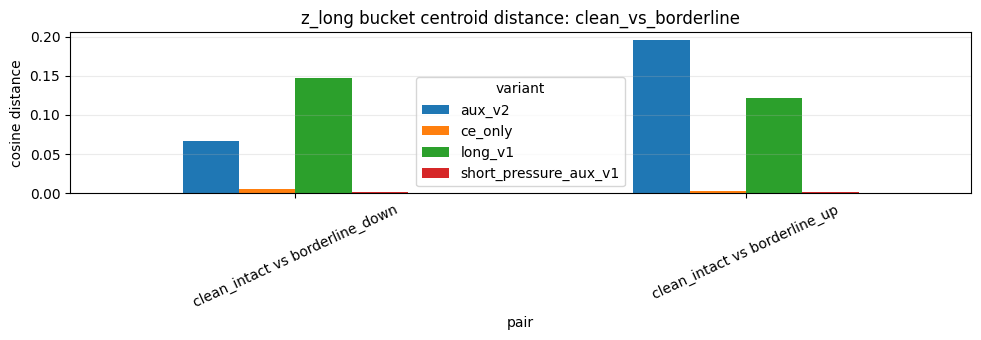

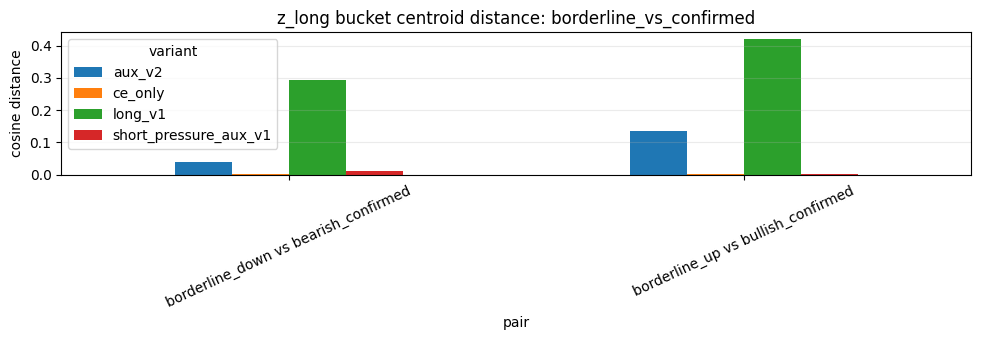

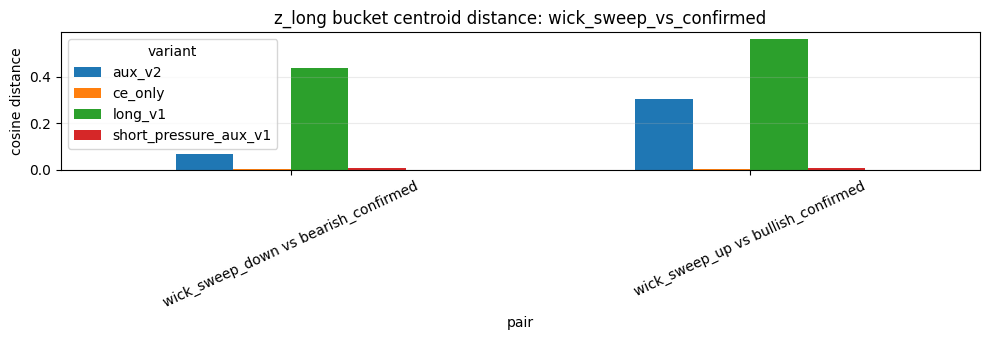

In [14]:
# z_long ve z_long_proj odağında kritik bucket çiftleri
focus_distance = bucket_distance_df[bucket_distance_df["embedding"].isin(["z_long", "z_long_proj"])]

# Ana okuma: z_long bucket centroid distance.
zlong_bucket_pivot = (
    focus_distance[focus_distance["embedding"] == "z_long"]
    .pivot_table(
        index=["group", "pair"],
        columns="variant",
        values="cosine_distance",
        aggfunc="first",
    )
    .sort_index()
)
display(zlong_bucket_pivot.round(4))

# İkincil kontrol: SupCon'un direkt çalıştığı z_long_proj uzayı.
zlong_proj_bucket_pivot = (
    focus_distance[focus_distance["embedding"] == "z_long_proj"]
    .pivot_table(
        index=["group", "pair"],
        columns="variant",
        values="cosine_distance",
        aggfunc="first",
    )
    .sort_index()
)
display(zlong_proj_bucket_pivot.round(4))

for group_name in ["clean_vs_borderline", "borderline_vs_confirmed", "wick_sweep_vs_confirmed"]:
    plot_data = bucket_distance_df[(bucket_distance_df["embedding"] == "z_long") & (bucket_distance_df["group"] == group_name)]
    if plot_data.empty:
        continue
    ax = plot_data.pivot(index="pair", columns="variant", values="cosine_distance").plot(
        kind="bar", figsize=(10, 3.5), rot=25
    )
    ax.set_title(f"z_long bucket centroid distance: {group_name}")
    ax.set_ylabel("cosine distance")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


### Borderline Holding/Reverted Split

`borderline_up/down` bucket'larını bir seviye daha açıyoruz:

- `holding`: anchor anında ilgili yöndeki excess hâlâ pozitif
- `reverted`: pressure olmuş ama anchor anında geri çekilmiş

Amaç: down tarafındaki `borderline_down vs bearish_confirmed` mesafesinin düşük olmasının özellikle `holding` örneklerden mi geldiğini görmek.

Bu bir açıklayıcı analizdir, ana karar metriği değildir. Eğer `reverted` örnekler confirmed'dan belirgin uzak, `holding` örnekler confirmed'a yakın çıksaydı, borderline/confirmed farkını pressure'ın devam edip etmemesiyle açıklayabilirdik. Gözlenen sonuç bu kadar temiz değil.


In [15]:
def structural_bucket_labels_with_holding(arrays: dict[str, np.ndarray], min_recent_break_bars: int = 2) -> np.ndarray:
    thresholds = _build_bucket_thresholds(arrays)
    labels = []
    for idx in range(len(arrays["labels"])):
        fields = _structural_state_fields(
            arrays,
            idx,
            min_recent_break_bars=min_recent_break_bars,
            thresholds=thresholds,
            pressure_labels=None,
        )
        confirmed = fields["confirmed_state"]
        maturity = fields["break_maturity"]
        direction = fields["structural_direction"]
        holding = fields["holding_status"]

        if confirmed == "intact" and maturity == "borderline" and direction in {"up", "down"}:
            bucket = f"borderline_{direction}_{holding}"
        elif confirmed == "bullish":
            bucket = "bullish_confirmed"
        elif confirmed == "bearish":
            bucket = "bearish_confirmed"
        else:
            bucket = "other"
        labels.append(bucket)
    return np.array(labels, dtype=object)

holding_labels = {name: structural_bucket_labels_with_holding(arrays) for name, arrays in latents.items()}

holding_count_rows = []
for variant, labels_ in holding_labels.items():
    values, counts = np.unique(labels_, return_counts=True)
    for value, count in zip(values, counts):
        if value != "other":
            holding_count_rows.append({"variant": variant, "bucket": value, "count": int(count)})

holding_counts_df = pd.DataFrame(holding_count_rows)
holding_counts_df.pivot(index="bucket", columns="variant", values="count").fillna(0).astype(int)


variant,aux_v2,ce_only,long_v1,short_pressure_aux_v1
bucket,,,,
bearish_confirmed,2558,2558,2558,2558
borderline_down_holding,96,96,96,96
borderline_down_reverted,237,237,237,237
borderline_up_holding,94,94,94,94
borderline_up_reverted,209,209,209,209
bullish_confirmed,2339,2339,2339,2339


In [16]:
HOLDING_PAIRS = [
    ("borderline_down_holding", "bearish_confirmed"),
    ("borderline_down_reverted", "bearish_confirmed"),
    ("borderline_up_holding", "bullish_confirmed"),
    ("borderline_up_reverted", "bullish_confirmed"),
]

holding_distance_rows = []
for variant, arrays in latents.items():
    labels_ = holding_labels[variant]
    for embedding_key in ["z_long", "z_long_proj"]:
        if embedding_key not in arrays:
            continue
        centroids = bucket_centroids(arrays, labels_, embedding_key=embedding_key, min_count=20)
        for left, right in HOLDING_PAIRS:
            if left not in centroids or right not in centroids:
                continue
            holding_distance_rows.append({
                "variant": variant,
                "embedding": embedding_key,
                "left": left,
                "right": right,
                "pair": f"{left} vs {right}",
                "cosine_distance": cosine_distance(centroids[left], centroids[right]),
                "left_count": int((labels_ == left).sum()),
                "right_count": int((labels_ == right).sum()),
            })

holding_distance_df = pd.DataFrame(holding_distance_rows)

zlong_holding_pivot = (
    holding_distance_df[holding_distance_df["embedding"] == "z_long"]
    .pivot_table(index="pair", columns="variant", values="cosine_distance", aggfunc="first")
    .sort_index()
)
display(zlong_holding_pivot.round(4))

zlong_proj_holding_pivot = (
    holding_distance_df[holding_distance_df["embedding"] == "z_long_proj"]
    .pivot_table(index="pair", columns="variant", values="cosine_distance", aggfunc="first")
    .sort_index()
)
display(zlong_proj_holding_pivot.round(4))


variant,aux_v2,ce_only,long_v1,short_pressure_aux_v1
pair,,,,
borderline_down_holding vs bearish_confirmed,0.0434,0.0028,0.3006,0.0100
borderline_down_reverted vs bearish_confirmed,0.0361,0.0002,0.2883,0.0118
borderline_up_holding vs bullish_confirmed,0.1749,0.0041,0.4702,0.0036
borderline_up_reverted vs bullish_confirmed,0.1187,0.0030,0.3978,0.0021


variant,aux_v2,long_v1,short_pressure_aux_v1
pair,,,
borderline_down_holding vs bearish_confirmed,0.0381,0.0674,0.0
borderline_down_reverted vs bearish_confirmed,0.0396,0.0616,0.0
borderline_up_holding vs bullish_confirmed,0.0542,0.0734,0.0
borderline_up_reverted vs bullish_confirmed,0.0390,0.0576,0.0


### Per-Symbol Kontrol

Eğer bir fark tek bir sembolden geliyorsa, global centroid mesafesi yanıltıcı olabilir. Aşağıdaki tablo `long_v1 z_long` için holding/reverted split mesafelerini sembol bazında hesaplar.


In [17]:
def bucket_centroids_for_mask(arrays, labels_, embedding_key, sample_mask, min_count=10):
    x = arrays[embedding_key].astype("float64")
    x = x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-12)
    centroids = {}
    for bucket in sorted(set(labels_.tolist())):
        mask = (labels_ == bucket) & sample_mask
        if int(mask.sum()) < min_count:
            continue
        centroid = x[mask].mean(axis=0)
        centroid = centroid / (np.linalg.norm(centroid) + 1e-12)
        centroids[bucket] = centroid
    return centroids

variant = "long_v1"
arrays = latents[variant]
labels_ = holding_labels[variant]
symbol_rows = []
for symbol in sorted(set(arrays["symbols"].astype(str).tolist())):
    symbol_mask = arrays["symbols"].astype(str) == symbol
    centroids = bucket_centroids_for_mask(arrays, labels_, "z_long", symbol_mask, min_count=10)
    for left, right in HOLDING_PAIRS:
        if left not in centroids or right not in centroids:
            continue
        symbol_rows.append({
            "symbol": symbol,
            "pair": f"{left} vs {right}",
            "cosine_distance": cosine_distance(centroids[left], centroids[right]),
            "left_count": int(((labels_ == left) & symbol_mask).sum()),
            "right_count": int(((labels_ == right) & symbol_mask).sum()),
        })

symbol_holding_df = pd.DataFrame(symbol_rows)
display(symbol_holding_df.pivot(index="pair", columns="symbol", values="cosine_distance").round(4))
display(symbol_holding_df.pivot(index="pair", columns="symbol", values="left_count").astype("Int64"))


symbol,BTC_USDT_15m,ETH_USDT_15m,SOL_USDT_15m,XRP_USDT_15m
pair,,,,
borderline_down_holding vs bearish_confirmed,0.2436,0.2997,0.3797,0.2839
borderline_down_reverted vs bearish_confirmed,0.2126,0.3046,0.3232,0.3327
borderline_up_holding vs bullish_confirmed,0.6046,0.4230,0.3773,0.4582
borderline_up_reverted vs bullish_confirmed,0.4103,0.3438,0.4596,0.3923


symbol,BTC_USDT_15m,ETH_USDT_15m,SOL_USDT_15m,XRP_USDT_15m
pair,,,,
borderline_down_holding vs bearish_confirmed,22,18,22,34
borderline_down_reverted vs bearish_confirmed,67,56,53,61
borderline_up_holding vs bullish_confirmed,27,23,26,18
borderline_up_reverted vs bullish_confirmed,64,59,41,45


Holding/reverted split nasıl okunmalı?

Bu split bir hipotez kontrolüdür. Beklenti şuydu:

```text
holding örnekler confirmed'a daha yakın,
reverted örnekler confirmed'dan daha uzak olabilir.
```

Fakat gözlenen sonuç bunu net doğrulamıyor. `long_v1 z_long` tarafında holding ve reverted mesafeleri birbirine yakın; hatta bazı yön/sembollerde holding daha uzak çıkıyor.

Bu yüzden önemli not:

> `borderline_up` / `borderline_down` arasındaki confirmed mesafe farkını holding vs reverted açıklamıyor.

Daha olası okuma: down yönlü borderline yapılar, geniş bağlamda bearish confirmed ailesine yapısal olarak daha yakın; up yönünde borderline ve confirmed merkezleri daha fazla ayrışıyor.

Per-symbol tablo bu farkın tek bir sembolden gelip gelmediğini kontrol etmek için var. Gözlenen patern tek sembole sıkışmıyorsa global structural fark hipotezi güçlenir; sadece tek sembolde görünüyorsa symbol/regime etkisi olabilir.

Bu nedenle bu bölümün sonucu şudur:

```text
holding/reverted ayrımı faydalı bir sanity check,
ama mevcut farkı açıklayan ana faktör gibi görünmüyor.
```


Bucket centroid distance nasıl okunmalı?

- **Clean vs borderline**: `clean_intact` ile `borderline_*` ayrışıyorsa, model intact içindeki pressure/maturity farkını taşıyor olabilir.
- **Borderline vs confirmed**: `borderline_down/up` ile aynı yönlü confirmed bucket çok yakınsa, model near-confirmation pressure ile confirmed state'i karıştırıyor olabilir.
- **Wick sweep vs confirmed**: wick sweep ile confirmed break ayrışıyorsa, model wick-only pressure'ı confirmed break'ten ayrı tutuyor demektir.

Bu bölümde ana karar `z_long` üzerinden okunmalı. `z_long_proj`, SupCon projection uzayının aynı domain ayrışmasını ne kadar taşıdığını görmek için ikincil kontroldür.

Gözlenen ana sonuç:

```text
long_v1 z_long, CE-only ve aux koşularına göre bucket centroidlerini çok daha iyi ayrıştırıyor.
```

Özellikle `wick_sweep_* vs confirmed` ve `borderline_* vs confirmed` çiftlerinde `long_v1`in mesafeleri belirgin yüksektir. Bu, branch-aware geometry'nin sadece 3 ana label değil, domain açısından önemli alt yapıları da taşıdığını gösterir.

Fakat iki uyarı var:

1. Up/down simetrik değildir. `borderline_up vs bullish_confirmed` mesafesi, `borderline_down vs bearish_confirmed` mesafesinden daha yüksektir.
2. Holding/reverted split bu farkı açıklamıyor.

Bu nedenle şu yorum daha makul:

```text
down yönlü near-confirmation yapılar bearish confirmed yapılarla daha doğal biçimde benzeşiyor olabilir;
up yönünde borderline ve confirmed merkezleri daha temiz ayrışıyor.
```

Bu bulgu yeni deney tasarımı açısından önemli: bütün borderline örnekleri aynı tip hata gibi ele almak yerine, yön ve bucket bazlı guardrail raporlamak gerekir.


## 10. İlk Yorum

Bu notebook'taki tabloları okurken şu sırayı kullan:

1. `z_long / z_short` norm oranına bak.
2. Classifier'ın long/short weight oranına bak.
3. Effective long/short katkıyı oku.
4. NN label/symbol agreement ile latent kalitesini kontrol et.
5. Centroid symbol/label oranıyla shortcut riskini kontrol et.
6. Bucket centroid distance ile domain-specific hard-case ayrışmasını kontrol et.

`ce_supcon_long_v1`in güçlü tarafı, bu metriklerin aynı anda iyi yönde olmasıdır:

- `z_long` aktif
- classifier long branch'i gerçekten kullanıyor
- effective long/short katkı CE-only seviyesinden ayrılıyor
- NN label agreement yüksek
- NN symbol agreement düşük
- centroid geometry label-dominant / symbol-suppressed
- bucket seviyesinde clean, borderline, wick-sweep ve confirmed yapılar CE-only/aux koşularına göre daha okunaklı ayrışıyor

Bu notebook'ta artık belirtilmiş olması gereken önemli sonuçlar:

```text
1. long_v1'in başarısı sadece classifier F1 değil, branch usage + geometry başarısı.
2. ce_only long branch'i zayıf kullanıyor; z_short baskın.
3. aux_v2 pressure sinyalini iyileştirse de z_long symbol shortcut riskini artırıyor.
4. short_pressure_aux_v1 pressure gradient'i izole ediyor ama z_long geometry'yi koruyamıyor.
5. z_long_proj normu yüksek diye tek başına iyi sayılmaz; projection space NN/symbol davranışıyla okunmalı.
6. Bucket centroid analizi long_v1'in 3-class label ötesinde structural alt yapıları taşıdığını gösteriyor.
7. Holding/reverted split, borderline up/down asimetrisini açıklamıyor; yön bazlı structural fark daha olası.
```

Bundan sonraki deneylerde sadece `val_macro_f1` veya pressure probe değil, en az şu guardrail'ler birlikte raporlanmalı:

- `z_long_norm / z_short_norm`
- classifier effective `long/short` contribution
- `z_long` ve `z_long_proj` NN label/symbol agreement
- `z_long` centroid `symbol/label` ratio
- kritik bucket çiftleri için `z_long` centroid distance
